In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('Data01.csv')

In [2]:
asd = data.loc[data['season']==2025][['pName', 'points', 'GP', 'points_per100']]
asd['PPG'] = asd['points'] / asd['GP']
asd = asd.loc[asd['GP']>40]
asd.drop(columns=['points', 'GP'], inplace=True)

ppg = asd.sort_values(by='PPG', ascending=False).head(10)[['pName', 'PPG']].sort_values(by='PPG', ascending=True)
ppg.columns = ['player', 'val']
ppg100 = asd.sort_values(by='points_per100', ascending=False).head(10)[['pName', 'points_per100']].sort_values(by='points_per100', ascending=True)
ppg100.columns = ['player', 'val']

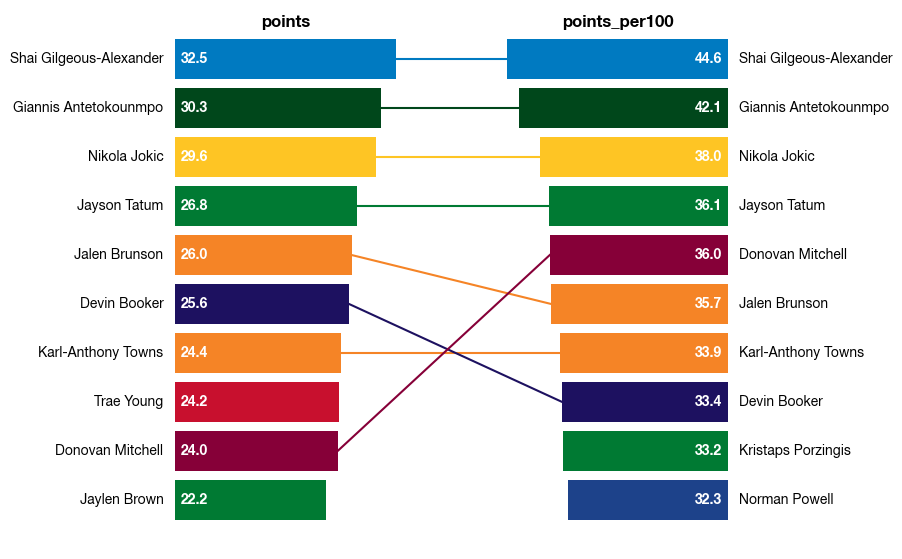

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

# Import HelveticaNeue
from matplotlib import font_manager

font_dirs = ['fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'Helvetica Neue'

left_players = ppg['player'].to_list()
right_players = ppg100['player'].to_list()

left_vals = ppg['val'].to_list()
right_vals = ppg100['val'].to_list()

left_pos = {player: i for i, player in enumerate(left_players)}
right_pos = {player: i for i, player in enumerate(right_players)}

fig, ax = plt.subplots(figsize=(10, 7))

# Colors (one per player)
colors = {'Devin Booker': '#1d1160',
          'Donovan Mitchell': '#860038',
          'Giannis Antetokounmpo': '#00471B',
          'Jalen Brunson': '#F58426',
          'Jaylen Brown': '#007A33',
          'Jayson Tatum': '#007A33',
          'Karl-Anthony Towns': '#F58426',
          'Kristaps Porzingis': '#007A33',
          'Nikola Jokic': '#FEC524',
          'Norman Powell': '#1d428a',
          'Shai Gilgeous-Alexander': '#007ac1',
          'Trae Young': '#C8102E'}

# Plot bars (as points/short lines)
max_ = 0.5

for p, y in left_pos.items():
    pts = round(left_vals[y], 1)
    width = (1*pts)/max(left_vals)
    
    ax.barh(y, width, left=0, color=colors[p])
    ax.text(-0.05, y, p, va='center', ha='right', fontsize=10) # Player name
    ax.text(0.15, y, pts, va='center', ha='right', fontsize=10, color='white', fontweight='bold') # Points

for p, y in right_pos.items():
    pts = round(right_vals[y], 1)
    width = (1*pts)/max(right_vals)
    
    ax.barh(y, width, left=2.5-width, color=colors[p])
    ax.text(2.55, y, p, va='center', ha='left', fontsize=10) # Player name
    ax.text(2.35, y, pts, va='center', ha='left', fontsize=10, color='white', fontweight='bold') # Points

# Draw connecting lines
for p in set(left_players).intersection(right_players):
    y1 = left_pos[p]
    y2 = right_pos[p]

    pts_left = left_vals[left_pos[p]]
    pts_right = right_vals[right_pos[p]]
    x1 = (1*pts_left)/max(left_vals)
    x2 = 2.5-(1*pts_right)/max(right_vals)
    ax.plot([x1, x2], [y1, y2], color=colors[p], linewidth=1.5)

# Title text
ax.text(0.5, 9.75, 'points', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(2, 9.75, 'points_per100', ha='center', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(-0.5, 3)
ax.set_ylim(-1, 10)
ax.axis('off')

plt.show()

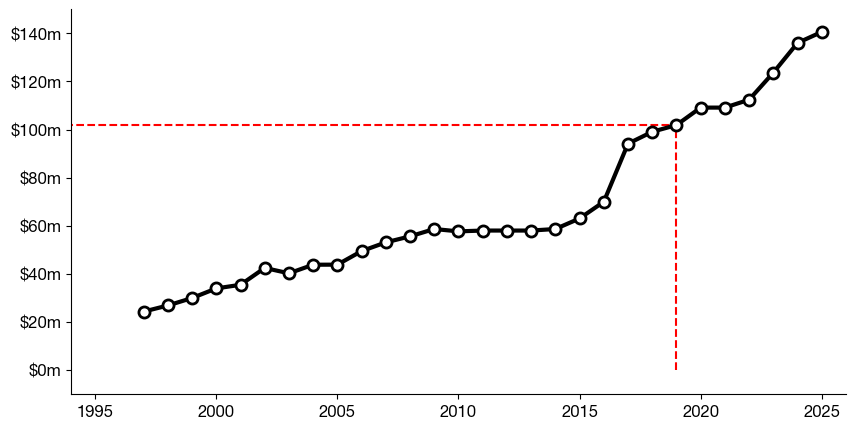

In [7]:
from matplotlib.ticker import FuncFormatter

cap_data = data[['season', 'cap']].drop_duplicates().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

# Additional info
plt.plot([2019, 2019], [0, 101869000], color='red', linestyle='--', linewidth=1.5)
plt.plot([0, 2019], [101869000, 101869000], color='red', linestyle='--', linewidth=1.5)

plt.plot(cap_data.iloc[:, 0], cap_data.iloc[:, 1], color='black', linewidth=3, marker='o', 
         markersize=8, markerfacecolor='white', markeredgecolor='black', markeredgewidth=2)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.0f}m'))
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(-10_000_000, 150_000_000)
ax.set_xlim(1994, 2026)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

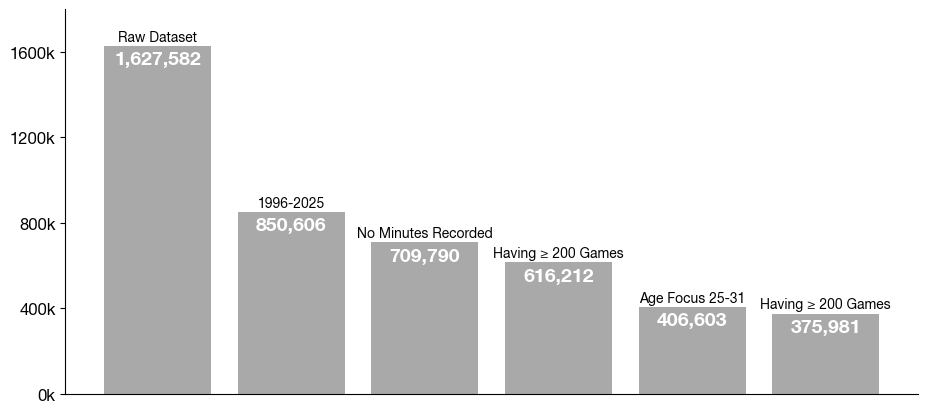

In [8]:
from matplotlib.ticker import MaxNLocator

# Outlier trimming steps
outlier = pd.read_csv('Outliers.csv')
out_plt = outlier.iloc[:-3]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(out_plt.index, out_plt['Number of Instances'], color='darkgray')

# Outlier step labels
for bar, step, value in zip(bars, out_plt['Outlier Step'], out_plt['Number of Instances']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 10_000, step, ha='center', va='bottom', fontsize=10)
    plt.text(bar.get_x() + bar.get_width() / 2, value - 100_000, f"{value:,}", ha='center', va='bottom', fontsize=14, color='w', fontweight='bold')

# Ticks and axes
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.tick_params(axis='both', labelsize=12)

ax.set_xticks([])
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax.set_ylim(0, 1_800_000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

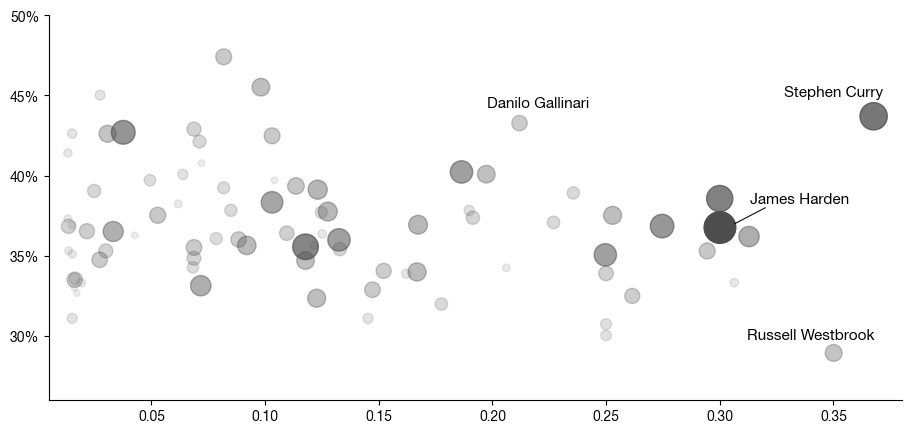

In [10]:
dum = data.loc[data['season']==2019][['pName', 'threePointersAttempted', 'threePointersMade', 'salary_adj']]
dum['3PT%'] = dum['threePointersMade'] / dum['threePointersAttempted']
dum = dum.loc[dum['threePointersAttempted']>=200]
a = dum.sort_values(by='3PT%', ascending=False)

# Normalize and scale for point size
dum['3PA_norm'] = (dum['threePointersAttempted'] - dum['threePointersAttempted'].min()) / (dum['threePointersAttempted'].max() - dum['threePointersAttempted'].min())
sizes = 20 + dum['3PA_norm'] * 500   # sizes
alphas = 0.1 + dum['3PA_norm'] * 0.9 # opacity

# Embed opacity to color vector
colors = np.zeros((len(alphas), 4))
colors[:, 0] = 0.3
colors[:, 1] = 0.3
colors[:, 2] = 0.3
colors[:, 3] = alphas

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(dum['salary_adj'], dum['3PT%'], s=sizes, color=colors)

# Player labels
plt.text(0.335, 0.385, 'James Harden', ha='center', va='center', fontsize=11)
ax.plot([0.3065, 0.32], [0.37, 0.38], color='black', linewidth=0.75)
plt.text(0.35, 0.452, 'Stephen Curry', ha='center', va='center', fontsize=11)
plt.text(0.34, 0.30, 'Russell Westbrook', ha='center', va='center', fontsize=11)
plt.text(0.22, 0.445, 'Danilo Gallinari', ha='center', va='center', fontsize=11)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(0.26, 0.5)
ax.set_xlim(0.005, 0.38)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

(176, 4)


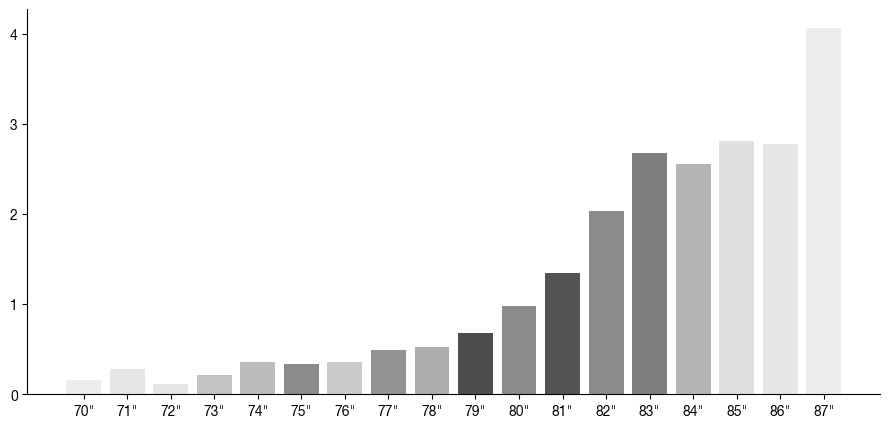

In [12]:
dum = data.loc[data['season']==2004][['pName', 'blocks_per100', 'height', 'salary_adj']].sort_values(by='blocks_per100', ascending=False)
a = dum.groupby('height', as_index=False).agg(blocks_per100=('blocks_per100', 'mean'), count=('blocks_per100', 'count'))
a = a.loc[(a['height']>69)&(a['height']<90)]

# Normalize and scale for bar opacity
a['count_norm'] = (a['count'] - a['count'].min()) / (a['count'].max() - a['count'].min())
alphas = 0.1 + a['count_norm'] * 0.9 # opacity

# Embed opacity to color vector
colors = np.zeros((len(a), 4))
colors[:, 0] = 0.3
colors[:, 1] = 0.3
colors[:, 2] = 0.3
colors[:, 3] = alphas

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(a['height'], a['blocks_per100'], color=colors)

# Bin size labels
#for bar, height, value, count in zip(bars, a['height'], a['blocks_per100'], a['count']):
#    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.1, count, ha='center', va='center', fontsize=12)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}"'))
ax.set_xticks(np.arange(a['height'].min(), a['height'].max() + 1, 1))
ax.set_yticks(np.arange(0, 5, 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [8]:
data.iloc[:, 4:].corr()['blocks_per100'].sort_values(ascending=False).head(7)

blocks_per100               1.000000
stocks_per100               0.827246
blocks                      0.823167
rebounds_per100             0.655210
reboundsOffensive_per100    0.637988
height                      0.634649
reboundsDefensive_per100    0.592210
Name: blocks_per100, dtype: float64

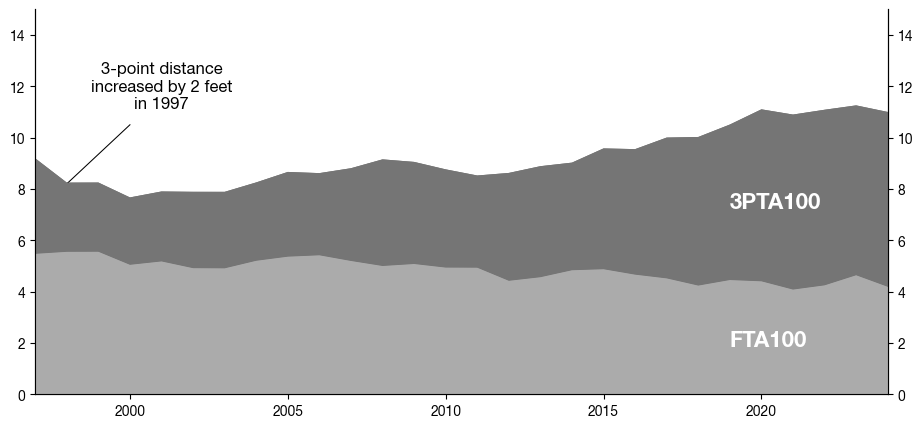

In [9]:
a = data[['pName', 'season', 'fieldGoalsAttempted_per100', 'threePointersAttempted_per100','freeThrowsAttempted_per100']]
a = a.groupby('season', as_index=False).agg(FGA=('fieldGoalsAttempted_per100', 'mean'), tPA=('threePointersAttempted_per100', 'mean'), FTA=('freeThrowsAttempted_per100', 'mean'))

fig, ax = plt.subplots(figsize=(11, 5))

#ax.plot(a['season'], a['FTA'], label='FTA') 
#ax.plot(a['season'], a['FTA'] + a['tPA'], label='FTA + 3PTA')

ax.stackplot(a['season'], a['FTA'], a['tPA'], labels=['blocks_per100', 'count'], colors=['#ababab', '#757575'])

# Right y-axis
ax2 = ax.twinx()
ax2.stackplot(a['season'], a['FTA'], a['tPA'], labels=['blocks_per100', 'count'], colors=['#ababab', '#757575'])

# Text
plt.text(2001, 12, '3-point distance\nincreased by 2 feet\nin 1997', ha='center', va='center', fontsize=12)
ax.plot([1998, 2000], [8.2, 10.5], color='black', linewidth=0.75)
plt.text(2019, 7.5, '3PTA100', ha='left', va='center', fontsize=16, color='white', fontweight='bold')
plt.text(2019, 2.1, 'FTA100', ha='left', va='center', fontsize=16, color='white', fontweight='bold')

ax.set_ylim(0, 15)
ax2.set_ylim(0, 15)
ax.set_xlim(1997, 2024)
ax2.set_xlim(1997, 2024)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.show()

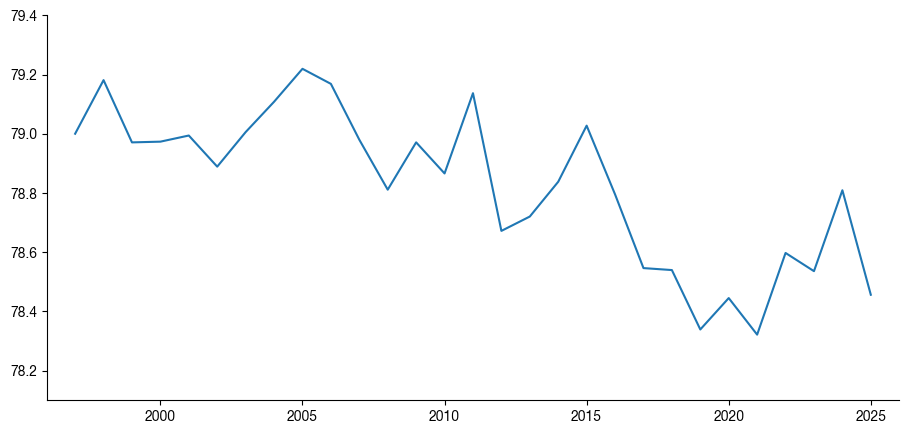

In [15]:
a = data.groupby('season', as_index=False)['height'].mean()

fig, ax = plt.subplots(figsize=(11, 5))

plt.plot(a['season'], a['height'])

# Text
#plt.text(2001, 12, '3-point distance\nincreased by 2 feet\nin 1997', ha='center', va='center', fontsize=12)
#ax.plot([1998, 2000], [8.2, 10.5], color='black', linewidth=0.75)
#plt.text(2019, 7.5, '3PTA100', ha='left', va='center', fontsize=16, color='white', fontweight='bold')
#plt.text(2019, 2.1, 'FTA100', ha='left', va='center', fontsize=16, color='white', fontweight='bold')

ax.set_ylim(78.1, 79.4)
ax.set_xlim(1996, 2026)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()